<a href="https://colab.research.google.com/github/Tauhid-Topu-007/cats-vs-dogs-CNN-project/blob/main/Cats_vs_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Deep learning require a lot of data**

In [1]:
!mkdir ~/.kaggle

In [2]:
!cp kaggle.json ~/.kaggle/

In [3]:
!kaggle datasets download salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:10<00:00, 111MB/s]



In [4]:
!unzip /content/dogsvscats.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/dogs/dog.4419.jpg  
  inflating: /content/train/dogs/dog.442.jpg  
  inflating: /content/train/dogs/dog.4420.jpg  
  inflating: /content/train/dogs/dog.4421.jpg  
  inflating: /content/train/dogs/dog.4422.jpg  
  inflating: /content/train/dogs/dog.4424.jpg  
  inflating: /content/train/dogs/dog.4425.jpg  
  inflating: /content/train/dogs/dog.4426.jpg  
  inflating: /content/train/dogs/dog.4427.jpg  
  inflating: /content/train/dogs/dog.4431.jpg  
  inflating: /content/train/dogs/dog.4433.jpg  
  inflating: /content/train/dogs/dog.4436.jpg  
  inflating: /content/train/dogs/dog.4438.jpg  
  inflating: /content/train/dogs/dog.4439.jpg  
  inflating: /content/train/dogs/dog.444.jpg  
  inflating: /content/train/dogs/dog.4440.jpg  
  inflating: /content/train/dogs/dog.4441.jpg  
  inflating: /content/train/dogs/dog.4442.jpg  
  inflating: /content/train/dogs/dog.4443.jpg  
  inflating: /content/train/dogs/dog.44

In [5]:
!pip3 install tensorflow numpy matplotlib keras

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from keras.utils import plot_model

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

In [7]:
cat_directory_path='/content/catsvsdogs/train/cats'
dogs_directory_path='/content/catsvsdogs/train/dogs'

In [8]:
len(os.listdir(cat_directory_path)), len(os.listdir(dogs_directory_path))

(10000, 10000)

**Loading some of the images**


**CV2 or numpy or PIL image**

array([[[101, 120, 155],
        [102, 121, 156],
        [102, 121, 156],
        ...,
        [117, 136, 174],
        [114, 133, 171],
        [110, 129, 167]],

       [[102, 121, 156],
        [103, 122, 157],
        [104, 123, 158],
        ...,
        [119, 138, 176],
        [116, 135, 173],
        [112, 131, 169]],

       [[105, 124, 159],
        [106, 125, 160],
        [106, 125, 160],
        ...,
        [121, 140, 178],
        [118, 137, 175],
        [114, 133, 171]],

       ...,

       [[ 53,  72,  99],
        [ 52,  71,  98],
        [ 51,  70,  97],
        ...,
        [ 32,  41,  61],
        [ 34,  45,  65],
        [ 38,  49,  71]],

       [[ 53,  72,  99],
        [ 52,  71,  98],
        [ 51,  70,  97],
        ...,
        [ 30,  37,  56],
        [ 31,  40,  60],
        [ 35,  43,  66]],

       [[ 53,  72,  99],
        [ 53,  72,  99],
        [ 51,  70,  97],
        ...,
        [ 25,  31,  50],
        [ 28,  35,  54],
        [ 32,  39,  59]]], dtype=uint8)
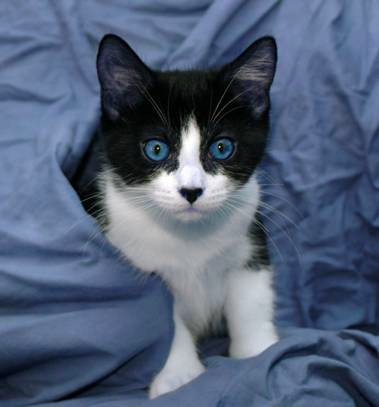

In [9]:
cat_image='/content/catsvsdogs/train/cats/cat.1002.jpg'
import cv2

img=cv2.imread(cat_image)
img

In [10]:
print(img)

[[[101 120 155]
  [102 121 156]
  [102 121 156]
  ...
  [117 136 174]
  [114 133 171]
  [110 129 167]]

 [[102 121 156]
  [103 122 157]
  [104 123 158]
  ...
  [119 138 176]
  [116 135 173]
  [112 131 169]]

 [[105 124 159]
  [106 125 160]
  [106 125 160]
  ...
  [121 140 178]
  [118 137 175]
  [114 133 171]]

 ...

 [[ 53  72  99]
  [ 52  71  98]
  [ 51  70  97]
  ...
  [ 32  41  61]
  [ 34  45  65]
  [ 38  49  71]]

 [[ 53  72  99]
  [ 52  71  98]
  [ 51  70  97]
  ...
  [ 30  37  56]
  [ 31  40  60]
  [ 35  43  66]]

 [[ 53  72  99]
  [ 53  72  99]
  [ 51  70  97]
  ...
  [ 25  31  50]
  [ 28  35  54]
  [ 32  39  59]]]


**Building the Model**

In [11]:
base_dir='/content/catsvsdogs/train'
train_datagen=ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [34]:

## Using 20% of data for validation
train_generator=train_datagen.flow_from_directory(
    base_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary',
    subset='training',
    shuffle=False
)

Found 16000 images belonging to 2 classes.


In [35]:
validation_generator=train_datagen.flow_from_directory(
    base_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 4000 images belonging to 2 classes.


In [36]:
train_generator.class_indices

{'cats': 0, 'dogs': 1}

**Building the Model**

In [37]:
model=models.Sequential([
    #layer 1
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    #layer 2
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    #layer 3
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    #layer 4
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(512,activation='relu'),
    layers.Dense(1,activation='sigmoid')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

#### 1.First Conv2D Layer
- Input shape:(150,150,3)
- Number of filter:32
-Filter size:(3,3)
- Parameters: $$(3 \times 3 \times 3+1) \times 32 = 896$$

#### 2.Second Conv2D Layer
- Input shape:(74,74,32)
- Number of filter:64
-Filter size:(3,3,32)
- Parameters: $$(3 \times 3 \times 32+1) \times 64 = 18,496$$

#### 3.Third Conv2D Layer
- Input channel:64
- Number of filter:128
-Filter size:(3,3)
- Parameters: $$(3 \times 3 \times 64+1) \times 128 = 73,856$$

#### 4.Fourth Conv2D Layer
- Input shape:(74,74,32)
- Number of filter:64
-Filter size:(3,3,32)
- Parameters: $$(3 \times 3 \times 128+1) \times 128 = 147,584$$

In [38]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy']
              )

In [39]:
history=model.fit(
      train_generator,
      epochs=10,
      validation_data=validation_generator
  )

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.4959 - loss: 0.7051 - val_accuracy: 0.5175 - val_loss: 0.6915
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.5808 - loss: 0.7357 - val_accuracy: 0.6148 - val_loss: 0.6666
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.6265 - loss: 0.6488 - val_accuracy: 0.6570 - val_loss: 0.6255
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.6681 - loss: 0.6126 - val_accuracy: 0.6812 - val_loss: 0.5981
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.7101 - loss: 0.5702 - val_accuracy: 0.7322 - val_loss: 0.5418
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.7511 - loss: 0.5102 - val_accuracy: 0.7615 - val_loss: 0.4980
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 37s 46ms/step - accuracy: 0.7935 - loss: 0.4397 - val_accuracy: 0.7755 - val_loss: 0.4758
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.8388 - loss: 0.3620 - 

In [40]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
print(acc,val_acc,loss,val_loss)

[0.4958750009536743, 0.5808125138282776, 0.6265000104904175, 0.6680625081062317, 0.7100625038146973, 0.7511249780654907, 0.7935000061988831, 0.8387500047683716, 0.8871250152587891, 0.940750002861023] [0.5174999833106995, 0.6147500276565552, 0.6570000052452087, 0.6812499761581421, 0.7322499752044678, 0.7615000009536743, 0.7754999995231628, 0.7667499780654907, 0.7879999876022339, 0.7829999923706055] [0.7050871253013611, 0.7356966137886047, 0.6488099694252014, 0.6125653982162476, 0.5702489614486694, 0.5102048516273499, 0.4396638572216034, 0.3620463013648987, 0.2601301074028015, 0.14952784776687622] [0.6915494203567505, 0.6666142344474792, 0.6254518032073975, 0.5980936884880066, 0.5418025255203247, 0.4979817867279053, 0.47577738761901855, 0.5193868279457092, 0.5166400074958801, 0.619276762008667]


Text(0.5, 1.0, 'Training and Validation Loss')

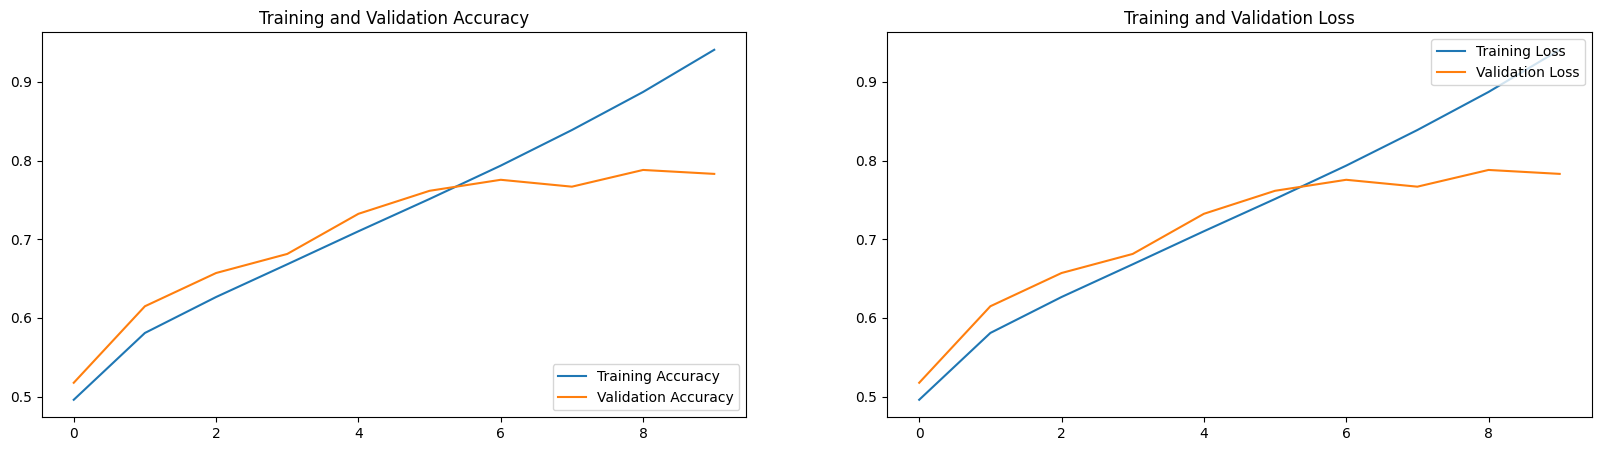

In [41]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range=range(len(acc))

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label="Training Accuracy")
plt.plot(epochs_range,val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(epochs_range,acc,label="Training Loss")
plt.plot(epochs_range,val_acc,label='Validation Loss')
plt.legend(loc='upper right')
plt.title("Training and Validation Loss")

**Testing and Inference**

In [42]:
test_datagen=ImageDataGenerator(rescale=1./255)

In [43]:
test_dir='/content/catsvsdogs/test'
test_generator=test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary',
    shuffle=False
)

Found 5000 images belonging to 2 classes.


In [44]:
## evaluate the model
test_loss,test_accuracy=model.evaluate(test_generator,steps=len(test_generator))

print(f"Test Loss :{test_loss}")
print(f"Test Accuracy :{test_accuracy}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.7840 - loss: 0.6322
Test Loss :0.6321631073951721
Test Accuracy :0.7839999794960022


## Confusion matrix
### Single Image Predictions

In [45]:
probabilities=model.predict(test_generator)
probabilities

250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step


array([[6.21901927e-06],
       [1.49898315e-02],
       [9.26792622e-03],
       ...,
       [1.00000000e+00],
       [9.97436762e-01],
       [9.96527493e-01]], dtype=float32)

In [46]:
predicted_classes=(probabilities>0.5).astype(int).squeeze()
predicted_classes

array([0, 0, 0, ..., 1, 1, 1])

In [47]:
test_generator.class_indices

{'cats': 0, 'dogs': 1}

In [48]:
class_labels=list(test_generator.class_indices.keys())
predicted_labels=[class_labels[i] for i in predicted_classes]

In [49]:
## get the true lables from the test generator
true_classes=test_generator.classes

## generate the confusion matrix
cm=confusion_matrix(true_classes,predicted_classes)
cm

array([[2059,  441],
       [ 639, 1861]])

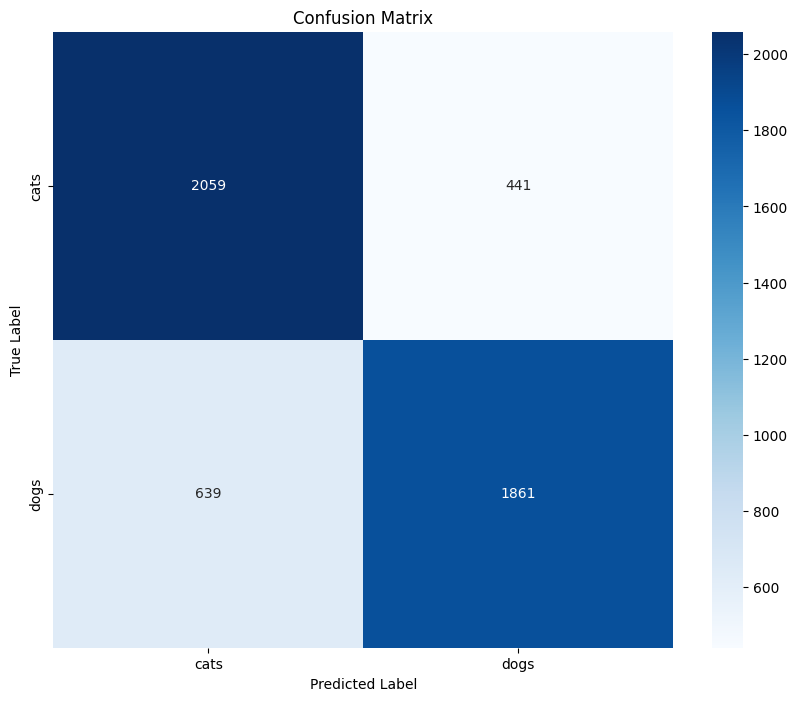

In [50]:
# plotting with seaborn
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_labels,yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [51]:
# Correct test image path
test_image = "/content/catsvsdogs/test/cats/cat.10109.jpg"

# Load image (resizing to model input size)
img = load_img(test_image, target_size=(150, 150))

# Convert to array
img_array = img_to_array(img)
print("Image array shape:", img_array.shape)

# Add batch dimension → (1, 150, 150, 3)
img_array = np.expand_dims(img_array, axis=0)
print("Batch added shape:", img_array.shape)

# Normalize (0–1)
img_array = img_array / 255.0
print("Final normalized shape:", img_array.shape)

Image array shape: (150, 150, 3)
Batch added shape: (1, 150, 150, 3)
Final normalized shape: (1, 150, 150, 3)


In [52]:
model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step


array([[0.19718136]], dtype=float32)

In [60]:
def make_prediction(image_path):
    # Load and resize image
    img = load_img(image_path, target_size=(150, 150))

    # Convert to array
    img_array = img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Normalize
    img_array = img_array / 255.0

    # Predict
    prediction = model.predict(img_array)
    print("Prediction Score:", prediction)

    # Plot Original Image
    plt.figure(figsize=(6, 3))

    # Left side → original
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # Right side → prediction
    plt.subplot(1, 2, 2)
    if prediction[0][0] > 0.5:
        plt.title("Predicted: Dog")
    else:
        plt.title("Predicted: Cat")

    plt.imshow(img)
    plt.axis('off')

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Prediction Score: [[0.87378687]]


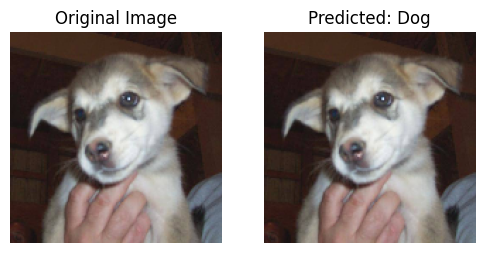

In [61]:
img_path='/content/test/dogs/dog.10196.jpg'
make_prediction(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Prediction Score: [[1.017021e-12]]


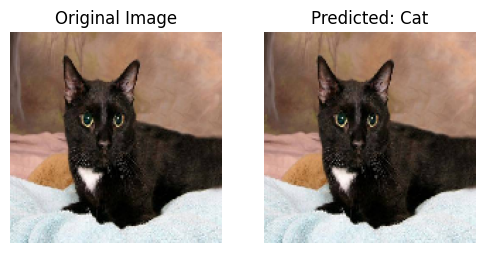

In [62]:
img_path='/content/test/cats/cat.10128.jpg'
make_prediction(img_path)